# Figure 3
种子及所选样本索引随数据保存。


In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

DATA_DIR = Path.cwd()
import secrets
from datetime import datetime
INITIAL_SEED = 141414
RUNS_DIR = DATA_DIR / 'output' / 'Figure3' / 'runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
RUN_POINTER = RUNS_DIR / 'current_run.txt'
if RUN_POINTER.exists():
    RUN_ID = RUN_POINTER.read_text(encoding='utf-8').strip()
    if Path(RUN_ID).name != RUN_ID:
        raise ValueError('Invalid run identifier')
else:
    RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    RUN_POINTER.write_text(RUN_ID, encoding='utf-8')
OUT_DIR = RUNS_DIR / RUN_ID
OUT_DIR.mkdir(exist_ok=True)
FS = 1200
TRIM = 60
N_SUBJECTS = 21
N_RESAMPLES = 1000
COLORS = {'Mooney': '#f0c808', 'Normal': '#e07a5f'}
BAR_COLORS = {'Mooney': '#fcf2b5', 'Normal': '#f7d8ce'}
ROIS = ['LV1', 'RV1', 'LV4', 'RV4', 'LOFA', 'ROFA', 'LFFA', 'RFFA', 'LSTSvp', 'RSTSvp']
ALL_ROIS = ['LV1', 'RV1', 'LV2', 'RV2', 'LV3', 'RV3', 'LV4', 'RV4', 'LOFA', 'ROFA', 'LFFA', 'RFFA', 'LVVC', 'RVVC', 'LSTSvp', 'RSTSvp', 'LSTSva', 'RSTSva', 'LTF', 'RTF']
PANELS = [('A', 'Left', (0.1, 0.2)), ('B', 'Right', (0.1, 0.2)),
          ('C', 'Left', (0.5, 1.0)), ('D', 'Right', (0.5, 1.0))]
plt.rcParams.update({'font.family': 'Arial', 'pdf.fonttype': 42, 'ps.fonttype': 42})

In [20]:
raw = sio.loadmat(DATA_DIR / 'source_timecourse_Noise_-0.25_0_Signal_0.1_0.35_dataset2.mat')
n_samples = raw['monney_timecourse_lh'].shape[-1]
time_erp = np.round(np.arange(TRIM + 1, n_samples + 1) / FS - 1, 12)
erp = {}
for condition, prefix in [('Mooney', 'monney'), ('Normal', 'normal')]:
    erp[condition] = {}
    for index, roi in enumerate(ALL_ROIS):
        hemisphere = 'lh' if roi.startswith('L') else 'rh'
        signal = np.asarray(raw[f'{prefix}_timecourse_{hemisphere}'][index // 2], dtype=float)
        assert signal.shape == (N_SUBJECTS, n_samples)
        erp[condition][roi] = np.abs(savgol_filter(signal, 61, 2, axis=-1))[:, TRIM:]
synergy = {}
for hemisphere, pathway in [('Left', 'LV1LOFA_to_LFFA'), ('Right', 'RV1ROFA_to_RFFA')]:
    mat = sio.loadmat(DATA_DIR / f'synergy_result_list_{pathway}_50ms_noresample.mat')
    synergy[hemisphere] = {}
    for condition, key in [('Mooney', 'Monney_synergy'), ('Normal', 'Normal_synergy')]:
        flat = np.asarray(mat[key], dtype=float).ravel()
        assert flat.size == N_SUBJECTS * len(time_erp)
        values = flat.reshape(N_SUBJECTS, len(time_erp))
        time_syn = np.round(np.arange(1, values.shape[1] + 1) / FS - (1 - (3.5 - values.shape[1] / FS)), 12)
        np.testing.assert_allclose(time_syn, time_erp, atol=1e-10)
        baseline = (time_syn >= -0.083) & (time_syn <= 0)
        synergy[hemisphere][condition] = values - values[:, baseline].mean(axis=1, keepdims=True)
# ERP 移除前 60 点后，与 synergy 按样本序号配对。
time_index = np.arange(-1 + 1/FS, 2.5, 1/FS)[:len(time_erp)]
assert len(time_index) == len(time_erp) == len(time_syn)
assert np.isfinite(time_index).all()

In [21]:
def window_mask(time, window):

    mask = (time > window[0]) & (time < window[1])
    if not mask.any():
        raise ValueError(f'Empty time window: {window}')
    return mask


def row_correlations(x, y):
    x = x - x.mean(axis=-1, keepdims=True)
    y = y - y.mean(axis=-1, keepdims=True)
    denominator = np.sqrt((x*x).sum(axis=-1) * (y*y).sum(axis=-1))
    with np.errstate(divide='ignore', invalid='ignore'):
        return (x*y).sum(axis=-1) / denominator


def correlation_stats(x, y, rng):
    if not (np.isfinite(x).all() and np.isfinite(y).all()):
        raise ValueError('Non-finite participant values')
    if np.std(x) == 0 or np.std(y) == 0:
        raise ValueError('Constant participant values')
    r = float(pearsonr(x, y)[0])
    permuted = np.stack([rng.permutation(y) for _ in range(N_RESAMPLES)])
    null_r = row_correlations(np.broadcast_to(x, permuted.shape), permuted)
    p = (np.count_nonzero(np.abs(null_r) >= abs(r)) + 1) / (N_RESAMPLES + 1)
    indices = rng.integers(0, len(x), size=(N_RESAMPLES, len(x)))
    boot = row_correlations(x[indices], y[indices])
    boot = boot[np.isfinite(boot)]
    if len(boot) < 0.95 * N_RESAMPLES:
        raise ValueError('Too many degenerate bootstrap samples')
    low, high = np.percentile(boot, [2.5, 97.5])
    return r, float(p), float(low), float(high), boot


def analyze_panel(panel, hemisphere, window, seed):
    erp_mask = window_mask(time_index, window)
    syn_mask = window_mask(time_index, window)
    rows, individual_rows = [], []
    bootstrap = {}
    panel_id = 'ABCD'.index(panel)
    for condition_id, condition in enumerate(['Mooney', 'Normal']):
        x = synergy[hemisphere][condition][:, syn_mask].mean(axis=1)
        for roi_id, roi in enumerate(ROIS):
            y = erp[condition][roi][:, erp_mask].mean(axis=1)
            rng = np.random.default_rng(np.random.SeedSequence([seed, panel_id, condition_id, roi_id]))
            r, p, low, high, boot = correlation_stats(x, y, rng)
            bootstrap[(condition, roi)] = boot
            rows.append(dict(Panel=panel, Hemisphere=hemisphere,
                             Start_ms=round(window[0]*1000), End_ms=round(window[1]*1000),
                             ROI=roi, Condition=condition, r=r, CI_lower=low, CI_upper=high,
                             Significant=int(p <= 0.05), p_permutation=p))
            for subject, (sx, ey) in enumerate(zip(x, y), start=1):
                individual_rows.append(dict(Panel=panel, Subject=subject, ROI=roi,
                                            Condition=condition, Synergy=sx, ERP=ey))
    return pd.DataFrame(rows), pd.DataFrame(individual_rows), bootstrap

In [22]:
def draw_panel(ax, bundle):
    panel = bundle['panel']
    hemisphere = bundle['hemisphere']
    window = bundle['window']
    table = pd.DataFrame(bundle['summary'])
    x = np.arange(len(ROIS))
    width = 0.34
    for condition, offset in [('Mooney', -width/2), ('Normal', width/2)]:
        group = table[table.Condition == condition].set_index('ROI').loc[ROIS]
        positions = x + offset
        ax.bar(positions, group.r, width, color=BAR_COLORS[condition], alpha=1.0, edgecolor='none')
        for roi_index, (xp, row) in enumerate(zip(positions, group.itertuples())):
            boot = np.asarray(bundle['bootstrap'][condition + ':' + row.Index])
            jitter_rng = np.random.default_rng(np.random.SeedSequence([bundle['config']['seed'], 99, 'ABCD'.index(panel), int(condition == 'Normal'), roi_index]))
            ax.scatter(xp + jitter_rng.uniform(-0.12, 0.12, len(boot)), boot,
                       s=1.2, color=COLORS[condition], alpha=1.0, linewidths=0,
                       rasterized=True, zorder=3)
            ax.vlines(xp, row.CI_lower, row.CI_upper, color='black', linewidth=1.5, zorder=5)
            ax.hlines([row.CI_lower, row.CI_upper], xp-0.045, xp+0.045, color='black', linewidth=1.5, zorder=5)
            ax.scatter(xp, row.r, s=15, facecolor='white', edgecolor='black', linewidth=1.0, zorder=6)
            p = row.p_permutation
            stars = '***' if p <= .001 else '**' if p <= .01 else '*' if p <= .05 else ''
            if stars:
                y = max(row.CI_upper, row.r) + .035 if row.r >= 0 else min(row.CI_lower, row.r) - .035
                ax.text(xp, y, stars, ha='center', va='bottom' if row.r >= 0 else 'top', fontsize=14)
    ax.axhline(0, color='0.35', lw=1.1)
    ax.set_xticks(x)
    ax.set_xticklabels(ROIS, rotation=45, ha='right', fontsize=20)
    ax.set_ylabel('Correlation coefficient (r)', fontsize=20)
    ax.set_title(f'{hemisphere} hemisphere ({window[0]*1000:.0f}–{window[1]*1000:.0f} ms)', fontsize=13, pad=12)
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-0.8, 1, .2))
    ax.set_yticklabels([-0.8,-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6,0.8],fontsize=20)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(1.2)
    ax.tick_params(axis='both', width=1.2, length=5)
    ax.text(-.13, 1.05, panel, transform=ax.transAxes, fontsize=19, fontweight='bold')


import json
import hashlib
import inspect
import shutil
from datetime import datetime, timezone

ROI_BASE = ['V1','V2','V3','V4','OFA','FFA','VVC','STSvp','STSva','TF']

def array_digest():
    h = hashlib.sha256()
    for condition in ['Mooney','Normal']:
        for roi in ALL_ROIS:
            h.update(np.ascontiguousarray(erp[condition][roi]).tobytes())
    for hemisphere in ['Left','Right']:
        for condition in ['Mooney','Normal']:
            h.update(np.ascontiguousarray(synergy[hemisphere][condition]).tobytes())
    return h.hexdigest()

INPUT_DIGEST = array_digest()
def current_config(seed=None):
    return dict(run_id=RUN_ID, seed=seed, n_resamples=N_RESAMPLES, fs=FS, trim=TRIM,
                subjects=N_SUBJECTS, endpoints='exclusive', time_reference='index_grid', erp_index_offset_ms=1000*TRIM/FS, baseline=[-0.083,0],
                input_sha256=INPUT_DIGEST, algorithm='index-paired-v1', rois=ROIS,
                profile_rois=ROI_BASE)

def save_panel_bundle(panel, hemisphere, window, seed=None):
    seed = secrets.randbits(64) if seed is None else int(seed)
    summary, individual, bootstrap = analyze_panel(panel, hemisphere, window, seed)
    mask = window_mask(time_index, window)
    profile = []
    prefix = 'L' if hemisphere == 'Left' else 'R'
    for condition in ['Mooney','Normal']:
        x = synergy[hemisphere][condition][:,mask].mean(axis=1)
        for roi in ROI_BASE:
            y = erp[condition][prefix+roi][:,mask].mean(axis=1)
            r = float(pearsonr(x,y)[0])
            profile.append(dict(ROI=roi, Condition=condition, Hemisphere=hemisphere,
                                r=r, Fisher_z=float(np.arctanh(np.clip(r,-.999999,.999999))),
                                Synergy=x.tolist(), ERP=y.tolist()))
    bundle = dict(panel=panel, hemisphere=hemisphere, window=list(window),
                  created_utc=datetime.now(timezone.utc).isoformat(), config=current_config(seed),
                  index_samples_ms=[float(time_index[mask][0]*1000),float(time_index[mask][-1]*1000)],
                  erp_event_samples_ms=[float(time_erp[mask][0]*1000),float(time_erp[mask][-1]*1000)],
                  sample_indices=np.flatnonzero(mask).tolist(),
                  summary=summary.to_dict('records'), individual=individual.to_dict('records'),
                  bootstrap={c+':'+r: values.tolist() for (c,r),values in bootstrap.items()}, profile=profile)
    destination = OUT_DIR / f'Figure3_{panel}.json'
    if destination.exists():
        history = OUT_DIR / 'history'; history.mkdir(exist_ok=True)
        shutil.copy2(destination, history / f'Figure3_{panel}_{datetime.now().strftime("%Y%m%d_%H%M%S_%f")}.json')
    temporary = destination.with_suffix('.tmp')
    temporary.write_text(json.dumps(bundle,ensure_ascii=False,allow_nan=False),encoding='utf-8')
    temporary.replace(destination)
    return bundle

def show_saved_panel(bundle):
    fig,ax = plt.subplots(figsize=(12,6),layout='constrained')
    draw_panel(ax,bundle)
    handles = [Line2D([0],[0],color='none',marker='o',markerfacecolor=COLORS[c],markeredgecolor='none',label=c) for c in ['Mooney','Normal']]
    handles += [Line2D([0],[0],color='none',marker='.',markerfacecolor='0.5',label=f"Bootstrap resamples ({bundle['config']['n_resamples']:,})")]
    handles += [Line2D([0],[0],color='black',marker='o',markerfacecolor='white',lw=1.5,label='Bootstrap 95% CI')]
    fig.legend(handles=handles,frameon=False,fontsize=8,loc='outside upper center',ncol=4)
    stem=OUT_DIR / f"Figure3_{bundle['panel']}"
    fig.savefig(stem.with_suffix('.png'),dpi=300,facecolor='white')
    fig.savefig(stem.with_suffix('.pdf'),facecolor='white')
    fig.savefig(stem.with_suffix('.tiff'),dpi=600,facecolor='white',pil_kwargs={'compression':'tiff_lzw'})
    plt.show()
    plt.close(fig)
    display(pd.DataFrame(bundle['summary']).rename(columns={'p_permutation': 'p_value'}).round(5))

def run_panel(panel, recompute=False):
    _, hemisphere, window = next(spec for spec in PANELS if spec[0]==panel)
    path = OUT_DIR / f'Figure3_{panel}.json'
    if path.exists() and not recompute:
        bundle=json.loads(path.read_text(encoding='utf-8'))
        if {k:v for k,v in bundle['config'].items() if k != 'seed'} != {k:v for k,v in current_config().items() if k != 'seed'}:
            raise ValueError('Saved parameters differ from current settings. Keep one consistent analysis specification for all panels.')
       
    else:
        bundle=save_panel_bundle(panel,hemisphere,window, seed=None if recompute else INITIAL_SEED)
    show_saved_panel(bundle)
    return bundle

## A · Left · 100–200 ms

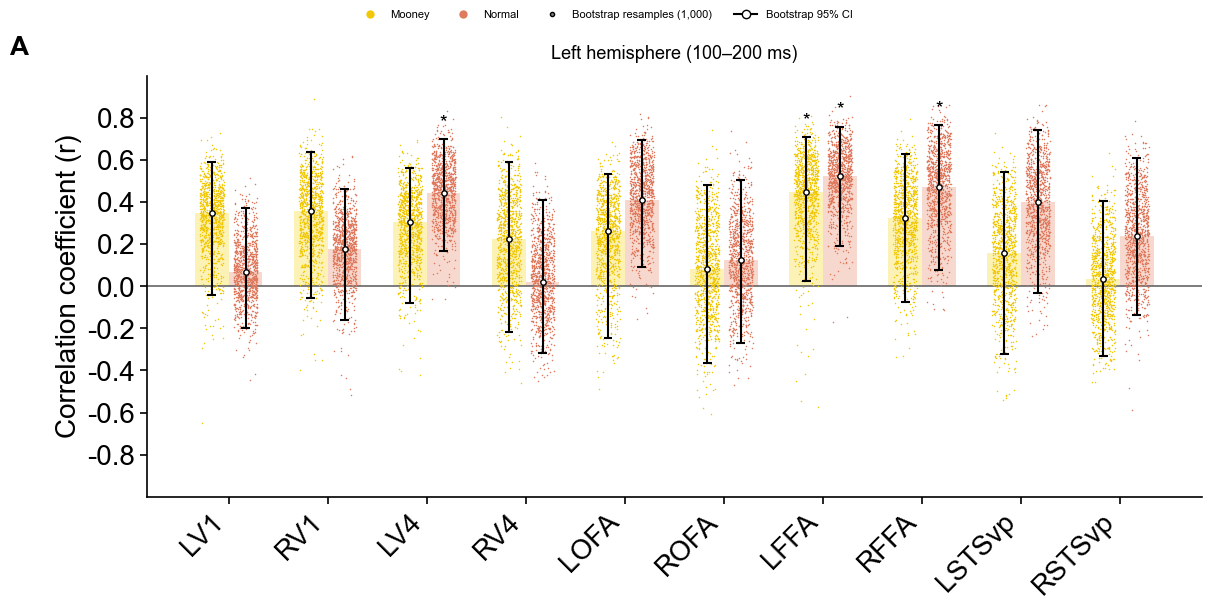

,Panel,Hemisphere,Start_ms,End_ms,ROI,Condition,r,CI_lower,CI_upper,Significant,p_value
0,A,Left,100,200,LV1,Mooney,0.34770,-0.04368,0.58778,0,0.12288
1,A,Left,100,200,RV1,Mooney,0.35511,-0.05759,0.63576,0,0.13586
2,A,Left,100,200,LV4,Mooney,0.30661,-0.08129,0.56348,0,0.16783
3,A,Left,100,200,RV4,Mooney,0.22498,-0.21952,0.59106,0,0.34366
4,A,Left,100,200,LOFA,Mooney,0.26384,-0.24777,0.53388,0,0.25574
5,A,Left,100,200,ROFA,Mooney,0.08196,-0.36445,0.48187,0,0.70130
6,A,Left,100,200,LFFA,Mooney,0.44864,0.02490,0.70744,1,0.04496
7,A,Left,100,200,RFFA,Mooney,0.32544,-0.07404,0.62733,0,0.14286
8,A,Left,100,200,LSTSvp,Mooney,0.15792,-0.32369,0.54247,0,0.50350
9,A,Left,100,200,RSTSvp,Mooney,0.03651,-0.33124,0.40634,0,0.86414


In [57]:
# True：重新随机并保存；False：读取已保存结果。
panel_A = run_panel('A', recompute=False)

## B · Right · 100–200 ms

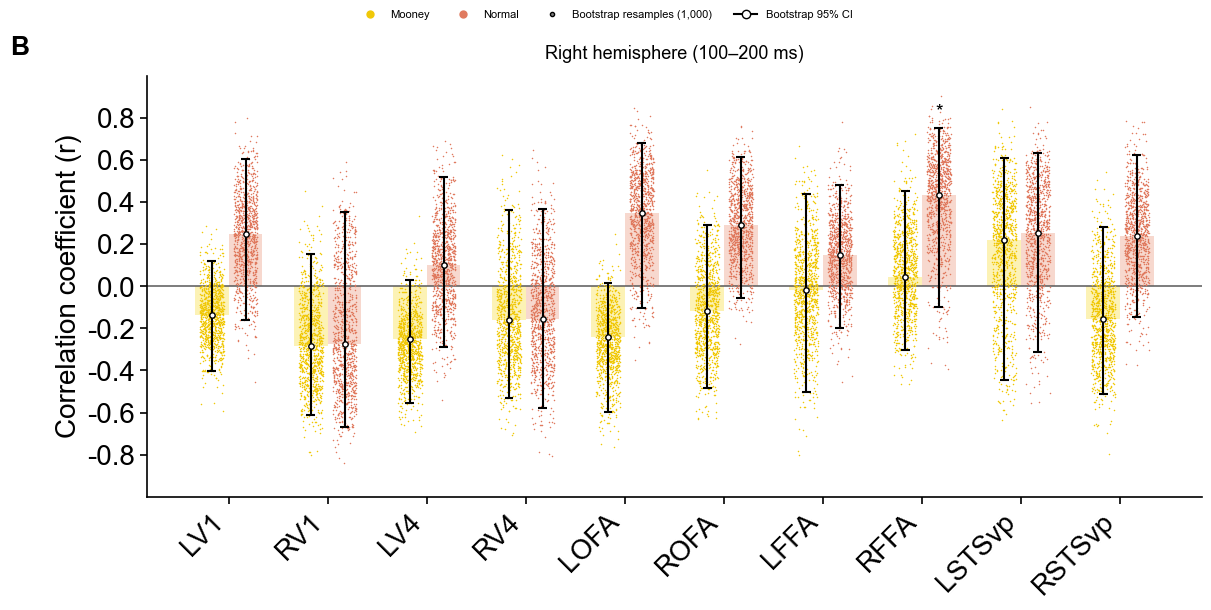

,Panel,Hemisphere,Start_ms,End_ms,ROI,Condition,r,CI_lower,CI_upper,Significant,p_value
0,B,Right,100,200,LV1,Mooney,-0.13715,-0.40056,0.12111,0,0.54246
1,B,Right,100,200,RV1,Mooney,-0.28572,-0.61354,0.15338,0,0.23676
2,B,Right,100,200,LV4,Mooney,-0.25144,-0.55629,0.02964,0,0.29271
3,B,Right,100,200,RV4,Mooney,-0.16243,-0.53232,0.36272,0,0.44356
4,B,Right,100,200,LOFA,Mooney,-0.24281,-0.59755,0.01434,0,0.23676
5,B,Right,100,200,ROFA,Mooney,-0.11631,-0.48517,0.28986,0,0.63337
6,B,Right,100,200,LFFA,Mooney,-0.01665,-0.50169,0.43826,0,0.94006
7,B,Right,100,200,RFFA,Mooney,0.04537,-0.30283,0.45430,0,0.84116
8,B,Right,100,200,LSTSvp,Mooney,0.22055,-0.44519,0.61134,0,0.33367
9,B,Right,100,200,RSTSvp,Mooney,-0.15669,-0.51137,0.28207,0,0.49451


In [24]:
# True：重新随机并保存；False：读取已保存结果。
panel_B = run_panel('B', recompute=True)

## C · Left · 500–1000 ms

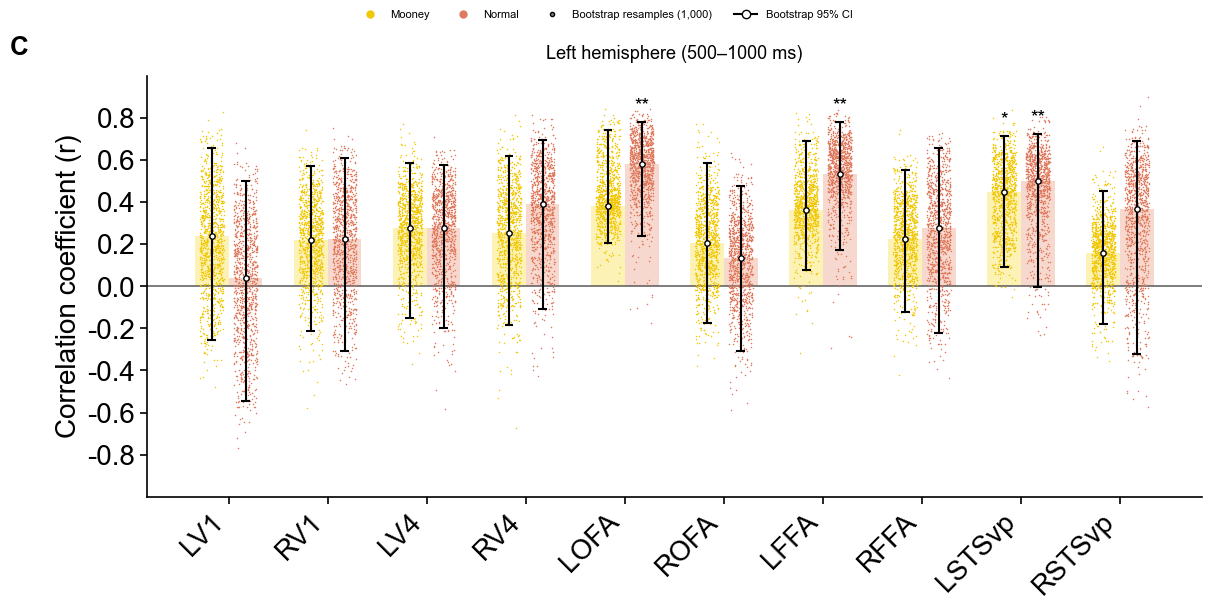

,Panel,Hemisphere,Start_ms,End_ms,ROI,Condition,r,CI_lower,CI_upper,Significant,p_value
0,C,Left,500,1000,LV1,Mooney,0.24003,-0.25533,0.65660,0,0.29970
1,C,Left,500,1000,RV1,Mooney,0.22095,-0.21492,0.56931,0,0.33666
2,C,Left,500,1000,LV4,Mooney,0.27576,-0.15048,0.58524,0,0.20280
3,C,Left,500,1000,RV4,Mooney,0.25320,-0.18274,0.61666,0,0.27972
4,C,Left,500,1000,LOFA,Mooney,0.37929,0.20671,0.74299,0,0.09091
5,C,Left,500,1000,ROFA,Mooney,0.20576,-0.17563,0.58545,0,0.41059
6,C,Left,500,1000,LFFA,Mooney,0.35969,0.07545,0.69153,0,0.10689
7,C,Left,500,1000,RFFA,Mooney,0.22660,-0.12267,0.55162,0,0.33666
8,C,Left,500,1000,LSTSvp,Mooney,0.44896,0.09046,0.71193,1,0.03796
9,C,Left,500,1000,RSTSvp,Mooney,0.15647,-0.17989,0.45423,0,0.46254


In [52]:
# True：重新随机并保存；False：读取已保存结果。
panel_C = run_panel('C', recompute=False)

## D · Right · 500–1000 ms

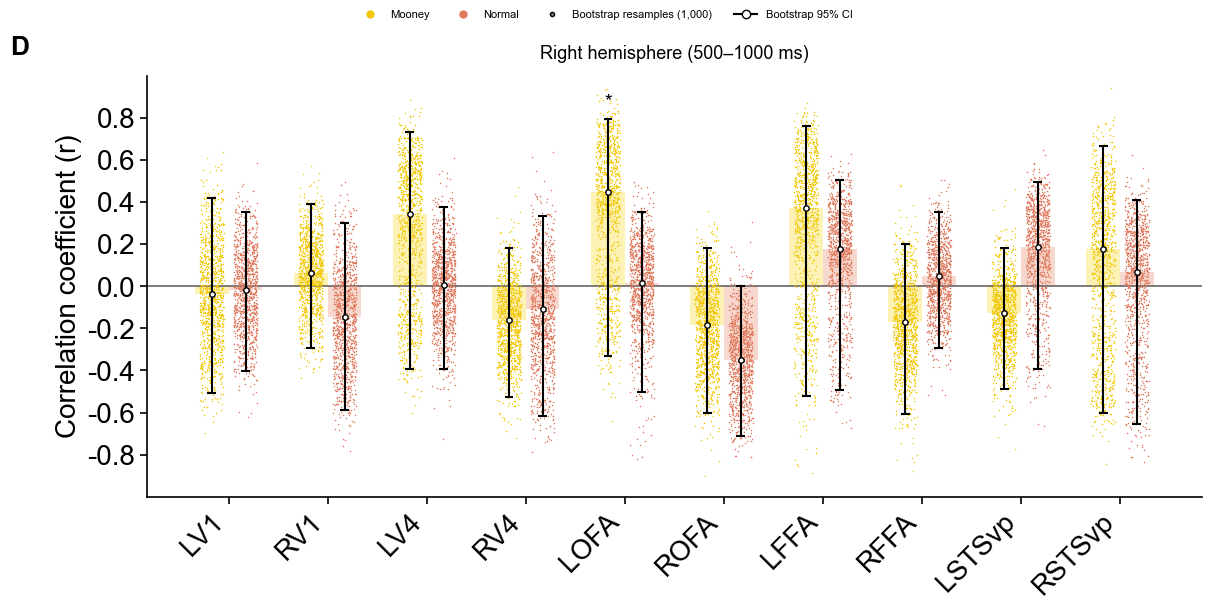

,Panel,Hemisphere,Start_ms,End_ms,ROI,Condition,r,CI_lower,CI_upper,Significant,p_value
0,D,Right,500,1000,LV1,Mooney,-0.03760,-0.50484,0.42042,0,0.87413
1,D,Right,500,1000,RV1,Mooney,0.06344,-0.29168,0.38852,0,0.79121
2,D,Right,500,1000,LV4,Mooney,0.34362,-0.39458,0.73086,0,0.13986
3,D,Right,500,1000,RV4,Mooney,-0.16032,-0.52383,0.17946,0,0.50350
4,D,Right,500,1000,LOFA,Mooney,0.44606,-0.33267,0.79486,1,0.04995
5,D,Right,500,1000,ROFA,Mooney,-0.18560,-0.59994,0.18220,0,0.39261
6,D,Right,500,1000,LFFA,Mooney,0.37158,-0.52002,0.76244,0,0.09890
7,D,Right,500,1000,RFFA,Mooney,-0.16917,-0.60793,0.20131,0,0.45654
8,D,Right,500,1000,LSTSvp,Mooney,-0.12946,-0.48933,0.17923,0,0.56743
9,D,Right,500,1000,RSTSvp,Mooney,0.17767,-0.60306,0.66737,0,0.41958


In [53]:
# True：重新随机并保存；False：读取已保存结果。
panel_D = run_panel('D', recompute=False)

## 从已保存的四个面板汇总统计

In [58]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, pearsonr
from IPython.display import display

runs_dir = Path.cwd() / 'output' / 'Figure3' / 'runs'
run_id = (runs_dir / 'current_run.txt').read_text(encoding='utf-8').strip()
if Path(run_id).name != run_id:
    raise ValueError('Invalid saved run identifier')
saved_dir = runs_dir / run_id
print('Reading current analysis:', run_id)
bundles = {}
expected = {'A':('Left',[.1,.2]),'B':('Right',[.1,.2]),'C':('Left',[.5,1.]),'D':('Right',[.5,1.])}
for panel,(hemisphere,window) in expected.items():
    path=saved_dir / f'Figure3_{panel}.json'
    if not path.exists(): raise FileNotFoundError(f'Run panel {panel} first: {path}')
    bundle=json.loads(path.read_text(encoding='utf-8'))
    assert (bundle['panel'],bundle['hemisphere'],bundle['window']) == (panel,hemisphere,window)
    assert bundle['config']['run_id'] == run_id
    assert len(bundle['summary'])==20 and len(bundle['profile'])==20
    for record in bundle['profile']:
        np.testing.assert_allclose(pearsonr(record['Synergy'],record['ERP'])[0],record['r'],atol=1e-12)
    bundles[panel]=bundle
configs=[{k:v for k,v in b['config'].items() if k != 'seed'} for b in bundles.values()]
if any(c!=configs[0] for c in configs[1:]):
    raise ValueError('Panel settings or input data differ. Recompute affected panels with one common specification before aggregation.')
summary=pd.concat([pd.DataFrame(b['summary']) for b in bundles.values()],ignore_index=True)
individual=pd.concat([pd.DataFrame(b['individual']) for b in bundles.values()],ignore_index=True)
summary.to_csv(saved_dir / 'Figure3_correlation_statistics.csv',index=False)
summary.drop(columns='p_permutation').to_csv(saved_dir / 'Figure3_source_data.csv',index=False)
individual.to_csv(saved_dir / 'Figure3_participant_values.csv',index=False)

rows=[]
for left_panel,right_panel in [('A','B'),('C','D')]:
    for condition in ['Mooney','Normal']:
        left=[r['Fisher_z'] for r in bundles[left_panel]['profile'] if r['Condition']==condition]
        right=[r['Fisher_z'] for r in bundles[right_panel]['profile'] if r['Condition']==condition]
        f,p=f_oneway(left,right)
        window=bundles[left_panel]['window']
        rows.append(dict(Start_ms=int(window[0]*1000),End_ms=int(window[1]*1000),Condition=condition,
                         Mean_z_left=np.mean(left),Mean_z_right=np.mean(right),F=f,df1=1,df2=18,p=p,
                         partial_eta2=f/(f+18)))
anova=pd.DataFrame(rows)
p=anova.p.to_numpy();order=np.argsort(p)
q=np.empty_like(p);q[order]=np.clip(np.minimum.accumulate((p[order]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1],0,1)
anova['q_FDR_4_tests']=q
anova['Significant_FDR']=(q<.05).astype(int)
anova.to_csv(saved_dir / 'Figure3_profile_ANOVA.csv',index=False)
print('Statistics read from the four saved panel bundles; no resampling performed.')
display(anova.round(6))

Reading current analysis: 20261007_210514_356017
Statistics read from the four saved panel bundles; no resampling performed.


,Start_ms,End_ms,Condition,Mean_z_left,Mean_z_right,F,df1,df2,p,partial_eta2,q_FDR_4_tests,Significant_FDR
0,100,200,Mooney,0.253709,-0.128044,22.699170,1,18,0.000155,0.557731,0.000310,1
1,100,200,Normal,0.351291,0.129469,4.391689,1,18,0.050520,0.196130,0.050520,0
2,500,1000,Mooney,0.308671,0.052929,6.432012,1,18,0.020690,0.263262,0.027587,1
3,500,1000,Normal,0.412962,-0.029814,30.167857,1,18,0.000032,0.626307,0.000130,1
